In [35]:
# ------------------------------------------------------------------------------------------------------------------------
# FANBEATS: Frequency and Attention-augmented Neural Basis Expansion Analysis for interpretable Time Series forecasting
#
# Copyright (c) 2026 Danish Abbas
#
# This file is part of the FANBEATS project.
# Licensed under the Creative Commons Attribution-NonCommercial
# 4.0 International License (CC BY-NC 4.0).
#
# See the LICENSE file in the root directory for full details.
# ------------------------------------------------------------------------------------------------------------------------

# FANBEATS Training and evaluation notebook


In [36]:
import os
import sys
import random
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent

sys.path.insert(0, str(REPO_ROOT))

print("Repo root added:", REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch as t
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 32 # setting it for reproducibility of results

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
t.manual_seed(SEED)

if t.cuda.is_available():
    t.cuda.manual_seed(SEED)
    t.cuda.manual_seed_all(SEED)

t.backends.cudnn.deterministic = True
t.backends.cudnn.benchmark = False

from models.fanbeats_model import FANBEATSModel # importing the FANBEATS model

from factories import nbeats_factories_modified
from trainers import trainer as model_trainer
from utils.sampler import TimeseriesSampler
from utils.ops import to_tensor, default_device

from configs import config
from utils import solar_wind_dataset as swd

print("Default device:", default_device())

Repo root added: d:\Data Science (Machine Learning)\Time Series Projects Implemented and Developed\FANBEATS
Default device: cuda


In [37]:
TRAIN_MODEL = False
LOAD_SAVED_MODEL = True
SAVE_MODEL = True
SAVE_RESULTS = True
USE_ZSCORE = True

LOOKBACK = config.LOOKBACK_LENGTH
HORIZON = config.FORECAST_HORIZON
MODE = config.NBEATS_MODE
EVAL_STEP = config.EVAL_WINDOW_STEP
BATCH_SIZE = config.BATCH_SIZE

EXPERIMENT_TAG = config.make_experiment_tag(MODE, LOOKBACK, HORIZON)

OUTPUT_ROOT = REPO_ROOT / config.OUTPUT_ROOT
TRAINED_MODELS_DIR = REPO_ROOT / config.TRAINED_MODELS_DIR
METRICS_DIR = REPO_ROOT / config.METRICS_DIR
PREDICTIONS_DIR = REPO_ROOT / config.PREDICTIONS_DIR
FIGURES_DIR = REPO_ROOT / config.FIGURES_DIR

for folder in [TRAINED_MODELS_DIR, METRICS_DIR, PREDICTIONS_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MODEL_PATH = TRAINED_MODELS_DIR / f"{EXPERIMENT_TAG}.pt"
TEST_METRICS_PATH = METRICS_DIR / f"metrics_test_{EXPERIMENT_TAG}.csv"
TEST_PREDS_PATH = PREDICTIONS_DIR / f"preds_test_{EXPERIMENT_TAG}.csv"
FIGURE_PATH = FIGURES_DIR / f"forecast_{EXPERIMENT_TAG}.png"

print("Experiment tag:", EXPERIMENT_TAG)
print("Model path:", MODEL_PATH)


Experiment tag: fanbeats_interpretable_lb96_h24
Model path: d:\Data Science (Machine Learning)\Time Series Projects Implemented and Developed\FANBEATS\outputs\trained_models\fanbeats_interpretable_lb96_h24.pt


In [38]:
# Load data (fixed split, no random splitting)
train_path = str(REPO_ROOT / config.TRAIN_FILE)
val_path = str(REPO_ROOT / config.VAL_FILE)
test_path = str(REPO_ROOT / config.TEST_FILE)

train_arr, val_arr, test_arr = swd.load_train_val_test(
    train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    column="speed",
)

 #merging both the training and validation based on original process of N-BEATS paper
train_full_arr = np.concatenate([train_arr, val_arr], axis=0)

train_dt, val_dt, test_dt = swd.load_train_val_test_datetimes(
    train_path=train_path,
    val_path=val_path,
    test_path=test_path,
    datetime_col="date_time",
    freq="h",
)

train_full_dt = train_dt.append(val_dt)

print("Raw split shapes:")
print("  Train:", train_full_arr.shape)
print("  Test :", test_arr.shape)

Raw split shapes:
  Train: (52608,)
  Test : (8760,)


In [39]:
if USE_ZSCORE:
    mu, sigma = swd.fit_standard_scaler(train_full_arr)
    train_norm = swd.apply_standard_scaler(train_full_arr, mu, sigma)
    test_norm = swd.apply_standard_scaler(test_arr, mu, sigma)
else:
    mu, sigma = 0.0, 1.0
    train_norm = train_full_arr.astype(np.float32)
    test_norm = test_arr.astype(np.float32)

train_list = swd.to_timeseries_list(train_norm)

print(f"Scaler -> mu={mu:.4f}, sigma={sigma:.4f}")
print("Train list lengths:", [len(x) for x in train_list])

Scaler -> mu=419.6638, sigma=90.6219
Train list lengths: [52608]


In [40]:

window_sampling_limit = len(train_list[0])
train_sampler = TimeseriesSampler(
    timeseries=train_list,
    insample_size=LOOKBACK,
    outsample_size=HORIZON,
    window_sampling_limit=window_sampling_limit,
    batch_size=BATCH_SIZE,
)
training_iterator = iter(train_sampler)

print("Training sampler ready.")


Training sampler ready.


In [41]:

if MODE == "interpretable":
    params = config.MODEL_PARAMS["interpretable"]
    base_model = nbeats_factories_modified.interpretable(
        input_size=LOOKBACK,
        output_size=HORIZON,
        trend_blocks=params["trend_blocks"],
        trend_layers=params["trend_layers"],
        trend_layer_size=params["trend_layer_size"],
        degree_of_polynomial=params["degree_of_polynomial"],
        seasonality_blocks=params["seasonality_blocks"],
        seasonality_layers=params["seasonality_layers"],
        seasonality_layer_size=params["seasonality_layer_size"],
        num_of_harmonics=params["num_of_harmonics"],
    )
else:
    raise ValueError(f"Unsupported mode: {MODE}")

# preparing the FANBEATS model
model = FANBEATSModel(nbeats_model = base_model, lookback_window = LOOKBACK)

model = model.to(default_device())
print(model.__class__.__name__)


FANBEATSModel


In [ ]:
if TRAIN_MODEL:
    model = model_trainer.trainer(
        model=model,
        training_set=training_iterator,
        timeseries_frequency=config.TIMESERIES_FREQUENCY,
        loss_name=config.LOSS_NAME,
        iterations=config.MAX_STEPS,
        learning_rate=config.LEARNING_RATE,
    )
    print("Training finished.")

    if SAVE_MODEL:
        t.save(model.state_dict(), MODEL_PATH)
        print("Saved model state_dict ->", MODEL_PATH)

elif LOAD_SAVED_MODEL:
    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"Saved model not found: {MODEL_PATH}")
    state_dict = t.load(MODEL_PATH, map_location=default_device())
    model.load_state_dict(state_dict)
    model = model.to(default_device())
    print("Loaded model state_dict ->", MODEL_PATH)
else:
    raise ValueError("Choose either TRAIN_MODEL=True or LOAD_SAVED_MODEL=True.")


Loaded model state_dict -> d:\Data Science (Machine Learning)\Time Series Projects Implemented and Developed\FANBEATS\outputs\trained_models\fanbeats_interpretable_lb96_h24.pt


In [ ]:

test_windows = swd.sliding_windows(
    test_norm,
    insample=LOOKBACK,
    outsample=HORIZON,
    step=EVAL_STEP,
)

test_preds, test_trues, test_starts = swd.evaluate_model_on_windows(
    model=model,
    windows=test_windows,
    to_tensor_fn=to_tensor,
    inverse_transform_fn=swd.inverse_standard_scaler,
    mu=mu,
    sigma=sigma,
    batch_size=BATCH_SIZE,
)

test_preds_df = swd.horizon_target_predictions_dataframe(
    preds=test_preds,
    trues=test_trues,
    start_indices=test_starts,
    split_name="test",
    datetime_index=test_dt,
    insample=LOOKBACK,
    horizon=HORIZON,
)

test_metrics = swd.compute_metrics_from_predictions_df(test_preds_df)

print("Test metrics      :", test_metrics)

Test metrics      : {'RMSE': 77.24222135403953, 'MAE': 54.64900292457357, 'CC': 0.7206858928957997}


In [ ]:

test_metrics_df = swd.metrics_dataframe(
    test_metrics, split_name="test", experiment_tag=EXPERIMENT_TAG
)

if SAVE_RESULTS:
    swd.save_dataframe_csv(TEST_METRICS_PATH, test_metrics_df)
    swd.save_dataframe_csv(TEST_PREDS_PATH, test_preds_df)

    print("Saved:")
    print(" ", TEST_METRICS_PATH)
    print(" ", TEST_PREDS_PATH)

display(test_metrics_df)

Saved:
  d:\Data Science (Machine Learning)\Time Series Projects Implemented and Developed\FANBEATS\outputs\metrics\metrics_test_fanbeats_interpretable_lb96_h24.csv
  d:\Data Science (Machine Learning)\Time Series Projects Implemented and Developed\FANBEATS\outputs\predictions\preds_test_fanbeats_interpretable_lb96_h24.csv


,split,experiment_tag,RMSE,MAE,CC
0,test,fanbeats_interpretable_lb96_h24,77.242221,54.649003,0.720686


Saved figure -> d:\Data Science (Machine Learning)\Time Series Projects Implemented and Developed\FANBEATS\outputs\figures\forecast_fanbeats_interpretable_lb96_h24.png


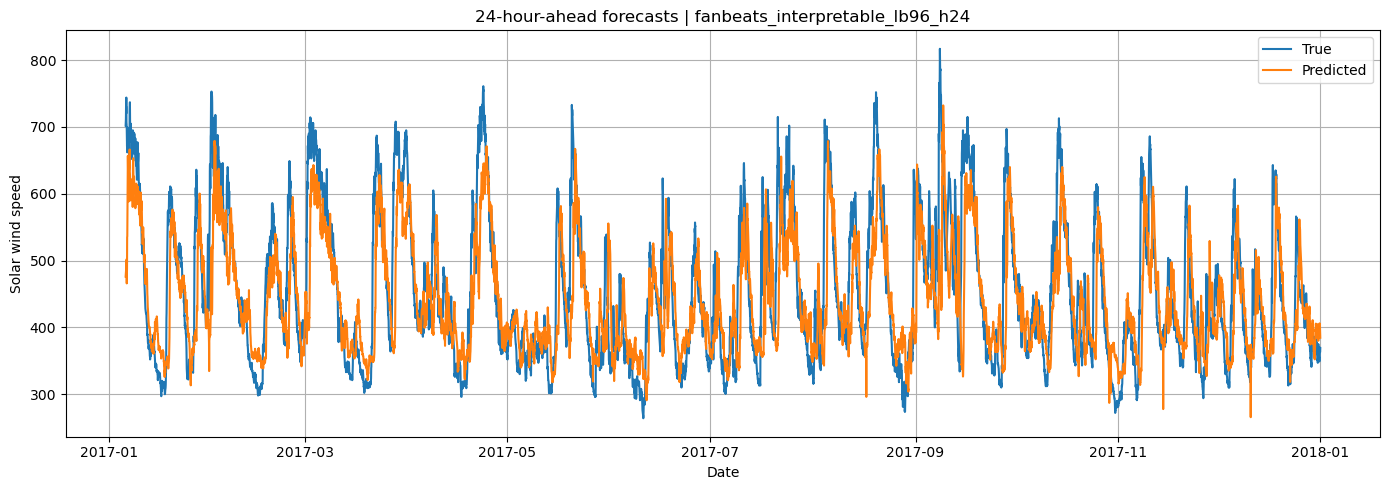

In [ ]:
plot_df = test_preds_df.copy()

plt.figure(figsize=(14, 5))
plt.plot(plot_df["date_time"], plot_df["y_true"], label="True")
plt.plot(plot_df["date_time"], plot_df["y_pred"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Solar wind speed")
plt.title(f"{HORIZON}-hour-ahead forecasts | {EXPERIMENT_TAG}")
plt.grid(True)
plt.legend()
plt.tight_layout()

if SAVE_RESULTS:
    plt.savefig(FIGURE_PATH, dpi=200, bbox_inches="tight")
    print("Saved figure ->", FIGURE_PATH)

plt.show()

In [ ]:
import pandas as pd
from pathlib import Path

def summarize_metrics(metrics_dir="../outputs/metrics", horizons=(24, 48, 72, 96)):
    metrics_dir = Path(metrics_dir)
    dfs = []
    
    for h in horizons:
        file_path = metrics_dir / f"metrics_test_fanbeats_{MODE}_lb96_h{h}.csv"
        if file_path.exists():
            df = pd.read_csv(file_path)
            df["horizon"] = h
            dfs.append(df)
        else:
            print(f"Warning: metrics file missing for horizon {h} -> {file_path}")
    
    if not dfs:
        raise FileNotFoundError("No metrics files found for the given horizons.")
    
    summary = pd.concat(dfs, ignore_index=True)
    
    for col in ["RMSE", "MAE", "CC"]:
        if col in summary.columns:
            summary[col] = summary[col].astype(float).round(3)
    
    return summary


summary_df = summarize_metrics()
print(summary_df)


  split                   experiment_tag     RMSE     MAE     CC  horizon
0  test  fanbeats_interpretable_lb96_h24   77.242  54.649  0.721       24
1  test  fanbeats_interpretable_lb96_h48  101.503  76.243  0.432       48
2  test  fanbeats_interpretable_lb96_h72  110.976  87.087  0.183       72
3  test  fanbeats_interpretable_lb96_h96  112.671  88.794  0.081       96


---
---
---